In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import make_pipeline

In [2]:
def linear_regression(x, y, xlabel, ylabel, title, x_pred=None):
    X = np.array(x).reshape(-1, 1)
    y = np.array(y)
    model = LinearRegression()
    model.fit(X, y)
    y_hat = model.predict(X)
    residuals = y - y_hat
    r2 = r2_score(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))
    slope = model.coef_[0]
    intercept = model.intercept_

    print(f"{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(f"  Slope      : {slope:+.4f}  ({ylabel} per {xlabel})")
    print(f"  Intercept  : {intercept:.4f}")
    print(f"  R²         : {r2:.4f}")
    print(f"  RMSE       : {rmse:.4f}")
    print(f"  n          : {len(y)}")
    print()

    x_line = np.array(x)
    if x_pred is not None:
        x_line = np.concatenate([x_line, np.array(x_pred)])
    y_line = model.predict(x_line.reshape(-1, 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1.scatter(x, y, color='steelblue', s=50, zorder=3, label='Observed')
    ax1.plot(x_line, y_line, color='tomato', linewidth=2, linestyle='--', label=f'Fit  (R²={r2:.3f})')
    if x_pred is not None:
        ax1.axvline(max(x), color='gray', linestyle=':', linewidth=1, label='Forecast start')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.legend()
    ax1.set_title('Scatter + Regression Line')
    ax1.grid(True, alpha=0.3)

    ax2.scatter(y_hat, residuals, color='mediumpurple', s=50, zorder=3)
    ax2.axhline(0, color='black', linewidth=1.2)
    ax2.set_xlabel('Fitted values')
    ax2.set_ylabel('Residual')
    ax2.set_title('Residuals vs. Fitted')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return model

In [3]:
def poly_regression(x, y, degree, xlabel, ylabel, title, x_pred=None):
    X = np.array(x).reshape(-1, 1)
    y = np.array(y)
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_hat = model.predict(X)
    residuals = y - y_hat
    r2 = r2_score(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))

    print(f"{'='*55}")
    print(f"  {title}  [degree={degree}]")
    print(f"{'='*55}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  n    : {len(y)}")
    print()

    x_line = np.linspace(min(x), max(x) + (len(x_pred) if x_pred else 0), 300)
    if x_pred is not None:
        x_line = np.linspace(min(x), max(x_pred), 300)
    y_line = model.predict(x_line.reshape(-1, 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f"{title} — Degree-{degree} Polynomial", fontsize=13, fontweight='bold')

    ax1.scatter(x, y, color='steelblue', s=50, zorder=3, label='Observed')
    ax1.plot(x_line, y_line, color='tomato', linewidth=2, label=f'Poly fit  (R²={r2:.3f})')
    if x_pred is not None:
        ax1.axvline(max(x), color='gray', linestyle=':', linewidth=1, label='Forecast start')
    ax1.set_xlabel(xlabel); ax1.set_ylabel(ylabel)
    ax1.legend(); ax1.set_title('Scatter + Polynomial Fit')
    ax1.grid(True, alpha=0.3)

    ax2.scatter(y_hat, residuals, color='mediumpurple', s=50, zorder=3)
    ax2.axhline(0, color='black', linewidth=1.2)
    ax2.set_xlabel('Fitted values'); ax2.set_ylabel('Residual')
    ax2.set_title('Residuals vs. Fitted')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return model

## Fossil Fuel CO2 Emissions vs. Time (1990–2022)

In [4]:
df_ff = pd.read_csv('data/Energy/FossilFuelCombustion.csv', header=None)
years_ff = df_ff.iloc[1, 1:].values.astype(float).astype(int)
co2_ff   = df_ff.iloc[2, 1:].values.astype(float)

fossil_df = pd.DataFrame({'Year': years_ff, 'CO2_MMT': co2_ff})
print(f"Years: {fossil_df.Year.min()} – {fossil_df.Year.max()}   |   "
      f"CO₂ range: {fossil_df.CO2_MMT.min():.1f} – {fossil_df.CO2_MMT.max():.1f} MMT")
fossil_df.tail()

Years: 1990 – 2022   |   CO₂ range: 4341.7 – 5744.1 MMT


,Year,CO2_MMT
28,2018,4988.2
29,2019,4852.6
30,2020,4341.7
31,2021,4654.3
32,2022,4699.4


  Fossil Fuel CO₂ Emissions vs. Time  [degree=2]
  R²   : 0.8182
  RMSE : 154.9108
  n    : 33



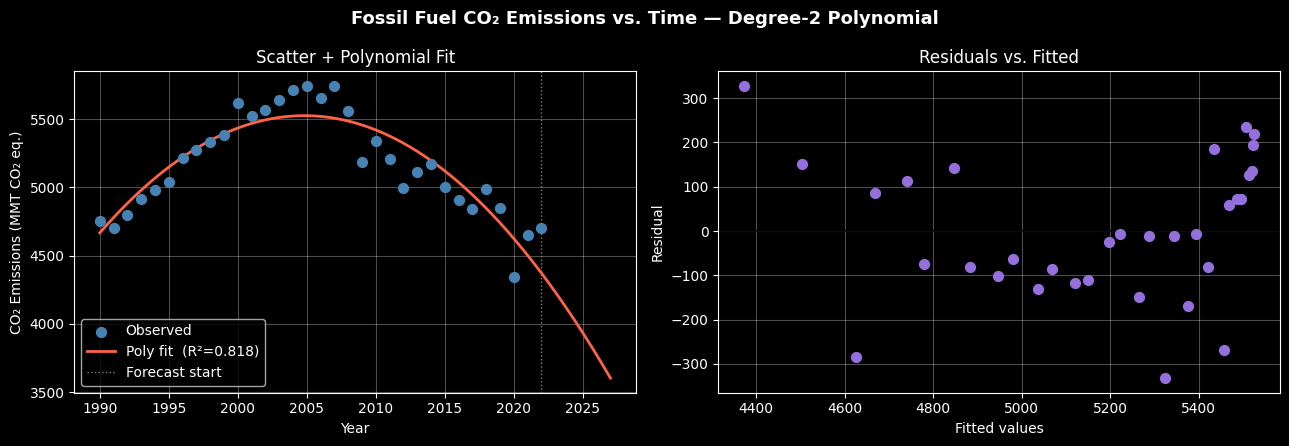

In [5]:
model_ff = poly_regression(
    x      = fossil_df['Year'],
    y      = fossil_df['CO2_MMT'],
    degree = 2,
    xlabel = 'Year',
    ylabel = 'CO₂ Emissions (MMT CO₂ eq.)',
    title  = 'Fossil Fuel CO₂ Emissions vs. Time',
    x_pred = [2023, 2024, 2025, 2026, 2027]
)

## EV Registrations vs. Time (2016–2024)

In [6]:
df_ev = pd.read_excel('data/EV_Registrations.xlsx', header=None)
ev_years = df_ev.iloc[0, 2:].values.astype(float).astype(int)
ev_regs  = df_ev.iloc[2, 2:].values.astype(float)

ev_df = pd.DataFrame({'Year': ev_years, 'EV_Registrations': ev_regs})
ev_df['EV_Registrations_M'] = ev_df['EV_Registrations'] / 1e6
print(f"Years: {ev_df.Year.min()} – {ev_df.Year.max()}   |   "
      f"EV reg range: {ev_df.EV_Registrations.min():,.0f} – {ev_df.EV_Registrations.max():,.0f}")
ev_df

Years: 2016 – 2024   |   EV reg range: 280,300 – 4,503,700


,Year,EV_Registrations,EV_Registrations_M
0,2016,280300.0,0.2803
1,2017,377100.0,0.3771
2,2018,572600.0,0.5726
3,2019,783600.0,0.7836
4,2020,1018900.0,1.0189
5,2021,1454400.0,1.4544
6,2022,2442300.0,2.4423
7,2023,3555900.0,3.5559
8,2024,4503700.0,4.5037


  U.S. EV Registrations vs. Time  [degree=2]
  R²   : 0.9920
  RMSE : 0.1274
  n    : 9



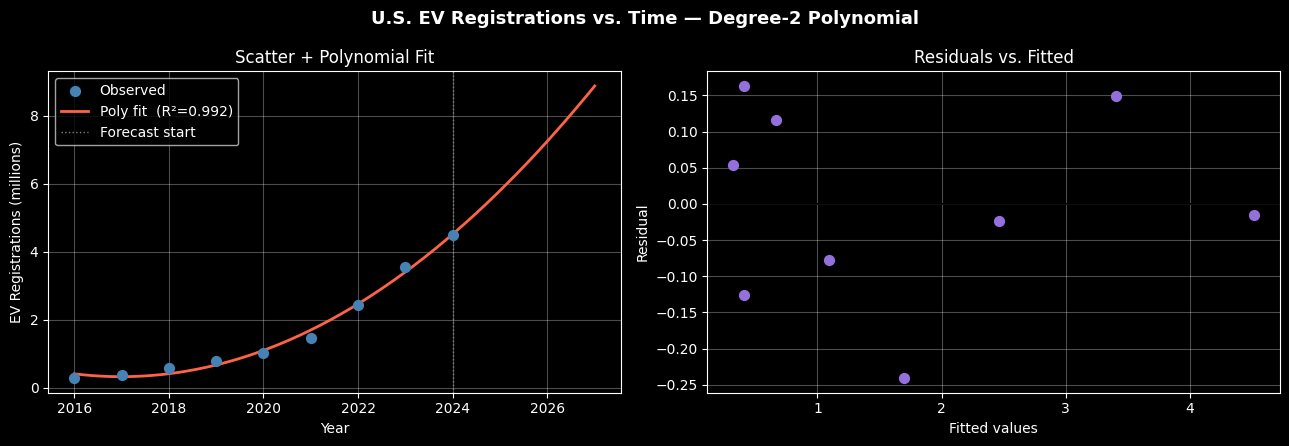

In [7]:
model_ev = poly_regression(
    x      = ev_df['Year'],
    y      = ev_df['EV_Registrations_M'],
    degree = 2,
    xlabel = 'Year',
    ylabel = 'EV Registrations (millions)',
    title  = 'U.S. EV Registrations vs. Time',
    x_pred = [2025, 2026, 2027]
)

## Agricultural GHG Emissions vs. Time (1990–2022)

In [8]:
df_ag = pd.read_csv('data/Agriculture/AgriculturalGeneralEmissions.csv', header=None)
ag_years = df_ag.iloc[1, 1:].values.astype(float).astype(int)
total_row_idx = None
for i, val in enumerate(df_ag.iloc[:, 0].values):
    if str(val).strip() == 'Total':
        total_row_idx = i
        break

if total_row_idx is not None:
    ag_total = df_ag.iloc[total_row_idx, 1:].values.astype(float)
else:
    ag_total = df_ag.iloc[2:, 1:].apply(pd.to_numeric, errors='coerce').sum(axis=0).values

ag_df = pd.DataFrame({'Year': ag_years, 'Emissions_MMT': ag_total})
ag_df = ag_df.dropna()

print(f"Years: {ag_df.Year.min()} – {ag_df.Year.max()}")
ag_df.head()

Years: 1990 – 2022


,Year,Emissions_MMT
0,1990,551.1
1,1991,543.2
2,1992,543.2
3,1993,564.4
4,1994,567.5


  Agricultural GHG Emissions vs. Time
  Slope      : +2.0073  (GHG Emissions (MMT CO₂ eq.) per Year)
  Intercept  : -3439.2519
  R²         : 0.7413
  RMSE       : 11.2896
  n          : 33



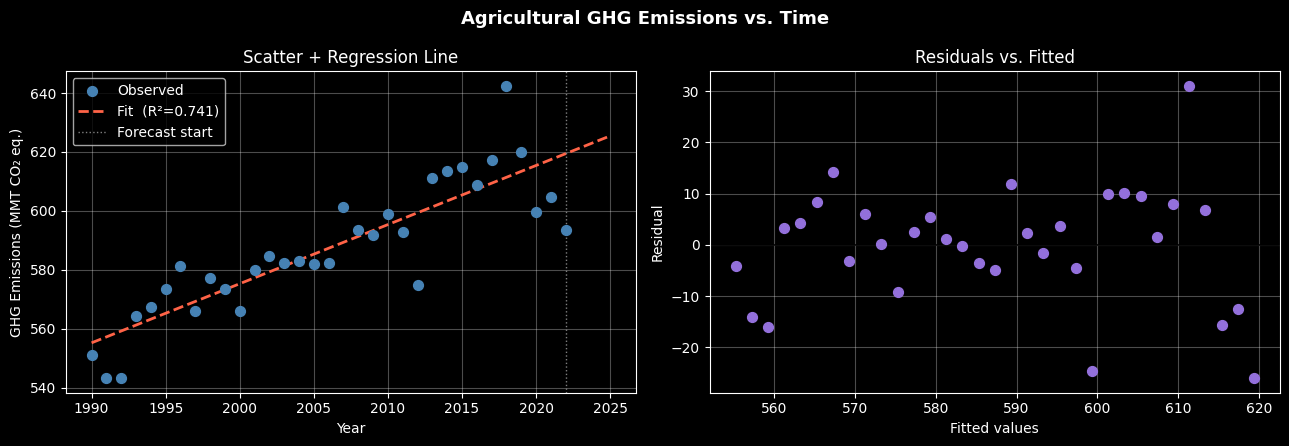

In [9]:
model_ag = linear_regression(
    x      = ag_df['Year'],
    y      = ag_df['Emissions_MMT'],
    xlabel = 'Year',
    ylabel = 'GHG Emissions (MMT CO₂ eq.)',
    title  = 'Agricultural GHG Emissions vs. Time',
    x_pred = [2023, 2024, 2025]
)